In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd

ticker = "TCS.NS"
stock_data = yf.download(ticker, start="2025-01-01", end="2026-01-01",auto_adjust=True)
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2025-01-01,3830.036621,3850.106540,3804.890560,3813.225893,763161
2025-01-02,3888.989746,3895.741869,3815.601341,3837.068252,1720835
2025-01-03,3818.348145,3892.901157,3811.270195,3892.901157,1791953
2025-01-06,3813.784912,3864.681853,3787.148863,3823.563848,2085593
2025-01-07,3751.665039,3856.020287,3736.065310,3832.364669,2669054


In [3]:
print("dataset shape (rows,columns):",stock_data.shape)
stock_data.describe()

dataset shape (rows,columns): (249, 5)


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
count,249.000000,249.000000,249.000000,249.000000,2.490000e+02
mean,3232.213170,3260.964206,3207.469076,3235.392267,2.682189e+06
std,310.034697,316.874786,306.574793,312.556690,1.269641e+06
min,2773.273438,2799.101392,2752.342317,2775.769681,0.000000e+00
25%,2987.480957,3009.084462,2964.917716,2986.041004,1.830520e+06
50%,3162.938232,3199.559901,3159.854367,3189.305669,2.519252e+06
75%,3350.022949,3380.421017,3321.710689,3349.975259,3.116051e+06
max,3996.418701,4026.081567,3937.092970,4006.569438,8.817365e+06


In [4]:
max_close=stock_data['Close'].max()
print("highest closing price:",max_close)

highest closing price: Ticker
TCS.NS    3996.418701
dtype: float64


In [5]:
stock_data['Daily_Range']= stock_data['High']-stock_data['Low']
print("\nTop 5 Days with Highest Volatility:")
print(stock_data[['Daily_Range']].sort_values(by='Daily_Range',ascending=False).head())


Top 5 Days with Highest Volatility:
Price      Daily_Range
Ticker                
Date                  
2025-04-07  223.220881
2025-03-21  143.455204
2025-04-30  136.483893
2025-02-28  135.630375
2025-05-12  121.687982


In [6]:
stock_data['Daily_Return']=stock_data['Close'].pct_change()*100
stock_data['50_MA']=stock_data['Close'].rolling(window=50).mean()
stock_data[['Close', 'Daily_Return', '50_MA']].dropna().tail(10)
stock_data.head()

Price,Close,High,Low,Open,Volume,Daily_Range,Daily_Return,50_MA
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,,,
Date,,,,,,,,
2025-01-01,3830.036621,3850.106540,3804.890560,3813.225893,763161,45.215980,NaN,NaN
2025-01-02,3888.989746,3895.741869,3815.601341,3837.068252,1720835,80.140528,1.539231,NaN
2025-01-03,3818.348145,3892.901157,3811.270195,3892.901157,1791953,81.630962,-1.816451,NaN
2025-01-06,3813.784912,3864.681853,3787.148863,3823.563848,2085593,77.532990,-0.119508,NaN
2025-01-07,3751.665039,3856.020287,3736.065310,3832.364669,2669054,119.954977,-1.628825,NaN


In [7]:
stock_data.columns=stock_data.columns.get_level_values(0)
bullish_days=stock_data[stock_data['Close']>stock_data['50_MA']]
print("Total Bullish Days (Close > 50_MA:", len(bullish_days))
bullish_days[['Close','50_MA','Daily_Return']].dropna().tail()

Total Bullish Days (Close > 50_MA: 75


Price,Close,50_MA,Daily_Return
Date,,,
2025-12-24,3198.595947,3010.513896,0.271898
2025-12-26,3161.010986,3016.887959,-1.175046
2025-12-29,3133.544678,3022.317578,-0.868909
2025-12-30,3129.015137,3027.639258,-0.144550
2025-12-31,3089.887939,3032.342222,-1.250464


In [8]:
import matplotlib.pyplot as plt

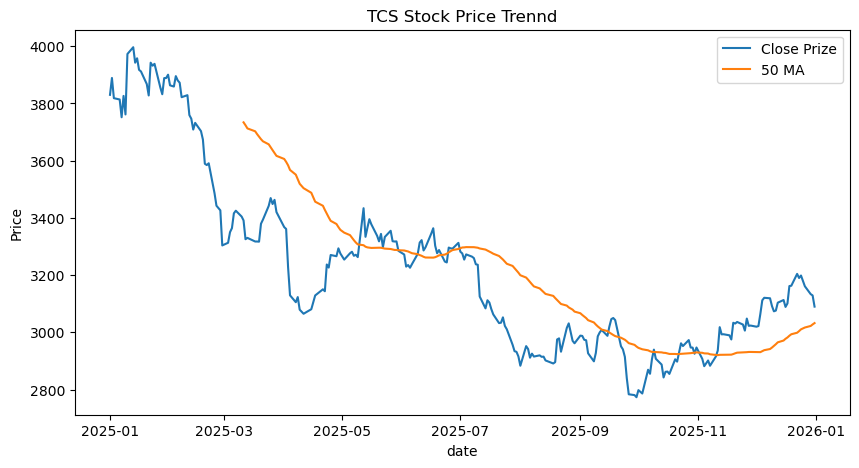

In [9]:
plt.figure(figsize=(10,5))
plt.plot(stock_data['Close'],label='Close Prize')
plt.plot(stock_data['50_MA'],label='50 MA')
plt.title('TCS Stock Price Trennd')
plt.xlabel('date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [11]:
stock_data['Target']=(stock_data['Close'].shift(-1)>stock_data['Close']).astype(int)
features= ['Close','50_MA','Daily_Return']
X=stock_data[features].dropna()
y=stock_data['Target'].loc[X.index]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)
model=RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train,y_train)
accuracy=model.score(X_test,y_test)
print("Model Accuracy:", round(accuracy *100,2), "%")

Model Accuracy: 50.0 %
